In [1]:
#minggu1-2
!pip install youtube-comment-downloader
!pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.4/300.4 kB 4.4 MB/s eta 0:00:00


In [2]:
from youtube_comment_downloader import YoutubeCommentDownloader
import pandas as pd

downloader = YoutubeCommentDownloader()

url1 = "https://youtu.be/9QnsB9SCzjw"
url2 = "https://youtu.be/q5x1SNjRQwY"

comments = []

for url in [url1, url2]:
    generator = downloader.get_comments_from_url(url)

    for comment in generator:
        comments.append(comment['text'])

df = pd.DataFrame(comments, columns=['komentar'])

print(df.head())
print("Jumlah data:", len(df))

                                            komentar
0  Paling suka klo dokter sudah bahas tentang pen...
1  Aku depresi karena kepercaan ku di hianatin ol...
2  Ternyata gw kaya gitu ... Hampir gila saya jan...
3  Aku seperti perlu dokter jiwa dok datangin kep...
4  Seperti anak kecil,semakin si anak rasa takut ...
Jumlah data: 2913


In [3]:
df.to_csv("komentar_mentah.csv", index=False)
print("Dataset berhasil disimpan")

Dataset berhasil disimpan


In [4]:
#minggu3-4

In [5]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2913 entries, 0 to 2912
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   komentar  2913 non-null   object
dtypes: object(1)
memory usage: 22.9+ KB
None
       komentar
count      2913
unique     2874
top          Up
freq          9


In [6]:
duplikat = df.duplicated().sum()

print("Jumlah data duplikat:", duplikat)

persentase = (duplikat / len(df)) * 100
print("Persentase duplikat:", round(persentase,2), "%")

Jumlah data duplikat: 39
Persentase duplikat: 1.34 %


In [7]:
from collections import Counter
import re

text = " ".join(df['komentar'].astype(str))

words = re.findall(r'\w+', text.lower())

counter = Counter(words)

print(counter.most_common(20))

[('dan', 877), ('aku', 678), ('yg', 666), ('di', 655), ('yang', 599), ('itu', 557), ('saya', 555), ('ini', 542), ('orang', 454), ('ke', 450), ('gw', 446), ('dokter', 430), ('ada', 400), ('bang', 400), ('bisa', 384), ('sama', 373), ('banget', 354), ('ga', 335), ('tapi', 322), ('jadi', 318)]


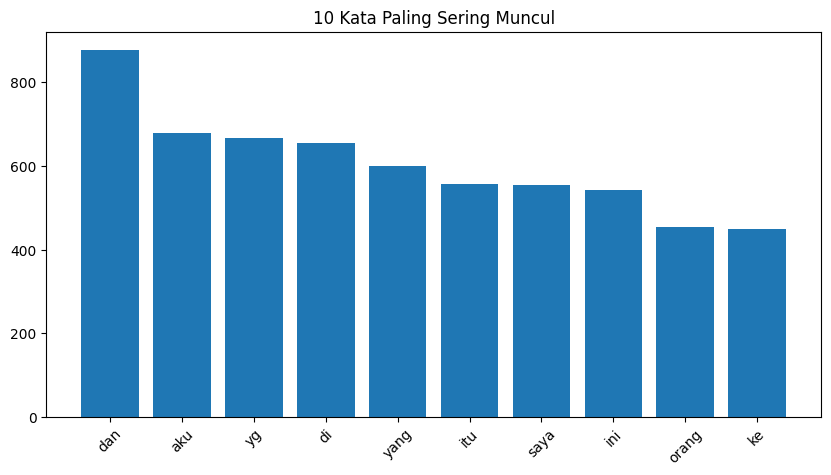

In [8]:
import matplotlib.pyplot as plt

kata = [x[0] for x in counter.most_common(10)]
jumlah = [x[1] for x in counter.most_common(10)]

plt.figure(figsize=(10,5))
plt.bar(kata, jumlah)
plt.title("10 Kata Paling Sering Muncul")
plt.xticks(rotation=45)
plt.show()

In [9]:
import re

def cek_noise(text):
    if re.search(r'http|www|@|#', str(text)):
        return "Noise"
    else:
        return "Clean"

df['noise'] = df['komentar'].apply(cek_noise)

print(df['noise'].value_counts())

noise
Clean    2761
Noise     152
Name: count, dtype: int64


In [10]:
#minggu5-6


In [11]:
df['clean'] = df['komentar'].str.lower()

df[['komentar','clean']].head()

,komentar,clean
0,Paling suka klo dokter sudah bahas tentang pen...,paling suka klo dokter sudah bahas tentang pen...
1,Aku depresi karena kepercaan ku di hianatin ol...,aku depresi karena kepercaan ku di hianatin ol...
2,Ternyata gw kaya gitu ... Hampir gila saya jan...,ternyata gw kaya gitu ... hampir gila saya jan...
3,Aku seperti perlu dokter jiwa dok datangin kep...,aku seperti perlu dokter jiwa dok datangin kep...
4,"Seperti anak kecil,semakin si anak rasa takut ...","seperti anak kecil,semakin si anak rasa takut ..."


In [12]:
import re

def cleaning(text):
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\d+', '', text)
    text = text.strip()

    return text

df['clean'] = df['clean'].apply(cleaning)

df.head()

,komentar,noise,clean
0,Paling suka klo dokter sudah bahas tentang pen...,Clean,paling suka klo dokter sudah bahas tentang pen...
1,Aku depresi karena kepercaan ku di hianatin ol...,Clean,aku depresi karena kepercaan ku di hianatin ol...
2,Ternyata gw kaya gitu ... Hampir gila saya jan...,Clean,ternyata gw kaya gitu hampir gila saya jantun...
3,Aku seperti perlu dokter jiwa dok datangin kep...,Clean,aku seperti perlu dokter jiwa dok datangin kep...
4,"Seperti anak kecil,semakin si anak rasa takut ...",Clean,seperti anak kecilsemakin si anak rasa takut a...


In [13]:
df = df[df['clean'].str.strip() != '']

print("Jumlah data setelah cleaning:", len(df))

Jumlah data setelah cleaning: 2812


In [14]:
df = df[df['clean'].str.split().str.len() >= 3]

print("Jumlah data setelah filtering:", len(df))

Jumlah data setelah filtering: 2515


In [15]:
#minggu7-8

In [16]:
slang_dict = {
    "aq": "saya",
    "gw": "saya",
    "gue": "saya",
    "gk": "tidak",
    "ga": "tidak",
    "ngga": "tidak",
    "bgt": "banget",
    "cape": "capek",
    "udh": "sudah",
    "sm": "sama",
    "krn": "karena",
    "trs": "terus",
    "pgn": "ingin",
    "nangis": "menangis",
    "bingungg": "bingung",
    "stress": "stres"
}

In [17]:
def normalize_text(text):
    words = text.split()

    normalized = []

    for word in words:
        normalized.append(slang_dict.get(word, word))

    return " ".join(normalized)

df['normalized'] = df['clean'].apply(normalize_text)

df[['clean','normalized']].head(10)

,clean,normalized
0,paling suka klo dokter sudah bahas tentang pen...,paling suka klo dokter sudah bahas tentang pen...
1,aku depresi karena kepercaan ku di hianatin ol...,aku depresi karena kepercaan ku di hianatin ol...
2,ternyata gw kaya gitu hampir gila saya jantun...,ternyata saya kaya gitu hampir gila saya jantu...
3,aku seperti perlu dokter jiwa dok datangin kep...,aku seperti perlu dokter jiwa dok datangin kep...
4,seperti anak kecilsemakin si anak rasa takut a...,seperti anak kecilsemakin si anak rasa takut a...
5,walaupun kalian mengalami hari yang berat belu...,walaupun kalian mengalami hari yang berat belu...
6,kaya w w w,kaya w w w
7,dokter tirta dan keluarga semoga bahagia dan s...,dokter tirta dan keluarga semoga bahagia dan s...
8,info doang guys saya cara sharing cerita keluh...,info doang guys saya cara sharing cerita keluh...
9,jika tak di pendam di usir dari rumah,jika tak di pendam di usir dari rumah


In [18]:
for i in range(10):
    print("Sebelum :", df['clean'].iloc[i])
    print("Sesudah :", df['normalized'].iloc[i])
    print("-"*50)

Sebelum : paling suka klo dokter sudah bahas tentang penyakit mental
Sesudah : paling suka klo dokter sudah bahas tentang penyakit mental
--------------------------------------------------
Sebelum : aku depresi karena kepercaan ku di hianatin oleh perselingkuhan tanpa ada kata maaf sedikitpun dari diaa maknnyaaa aku jadi depresi gini
Sesudah : aku depresi karena kepercaan ku di hianatin oleh perselingkuhan tanpa ada kata maaf sedikitpun dari diaa maknnyaaa aku jadi depresi gini
--------------------------------------------------
Sebelum : ternyata gw kaya gitu  hampir gila saya jantungan  gara rokok juga deh terlalu rilex otak nya  tapi ada kehidupan di otak yang lagi panik jadi kaya kosong  saya mau minta tolong ke ortu malu jantungan dan kaya hampir gila saya minta tolong ke allah aja lailahailallah dan yang biasa nya jarang saya sebut malah kesebut  islam juga ngajarin psikologi sih tapi orang muslim yang di deket gw bikin gw gk suka belajar islam  mereka bajingan
Sesudah : ternyata 

In [19]:
#minggu9-10

In [20]:
def labeling(text):

    text = text.lower()

    if "capek" in text or "lelah" in text or "stres" in text:
        return "Stress"

    elif "sedih" in text or "menangis" in text or "depresi" in text:
        return "Depresi"

    elif "cemas" in text or "takut" in text or "khawatir" in text:
        return "Cemas"

    else:
        return "Normal"

df['label'] = df['normalized'].apply(labeling)

df[['normalized','label']].head(20)

,normalized,label
0,paling suka klo dokter sudah bahas tentang pen...,Normal
1,aku depresi karena kepercaan ku di hianatin ol...,Depresi
2,ternyata saya kaya gitu hampir gila saya jantu...,Normal
3,aku seperti perlu dokter jiwa dok datangin kep...,Normal
4,seperti anak kecilsemakin si anak rasa takut a...,Cemas
5,walaupun kalian mengalami hari yang berat belu...,Normal
6,kaya w w w,Normal
7,dokter tirta dan keluarga semoga bahagia dan s...,Normal
8,info doang guys saya cara sharing cerita keluh...,Normal
9,jika tak di pendam di usir dari rumah,Normal


In [21]:
print(df['label'].value_counts())

label
Normal     2083
Depresi     243
Stress      134
Cemas        55
Name: count, dtype: int64


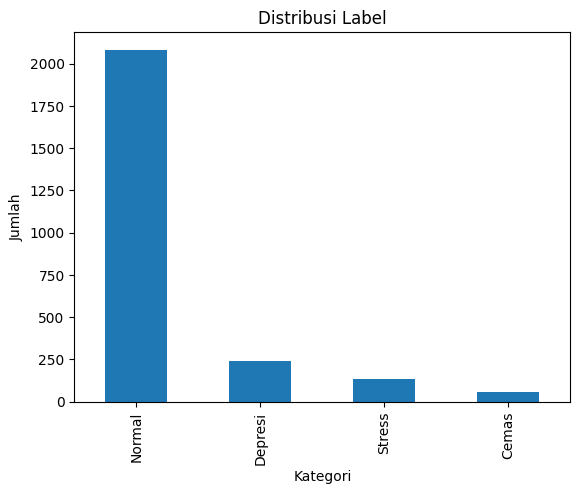

In [22]:
df['label'].value_counts().plot(kind='bar')

plt.title("Distribusi Label")
plt.xlabel("Kategori")
plt.ylabel("Jumlah")
plt.show()

In [23]:
#minggu11-12

In [24]:
sample_data = df.sample(100)

sample_data[['komentar','normalized','label']]

,komentar,normalized,label
1379,Banyakin bahas psikolog bang seru banget😂❤,banyakin bahas psikolog bang seru banget,Normal
2290,"Bang Radit, invite dokter tono spog dongg (@do...",bang radit invite dokter tono spog dongg pasti...,Normal
76,Dr tirta terang banget kalok jelasin depresi dll,dr tirta terang banget kalok jelasin depresi dll,Depresi
564,Kasih golok aja orang tua nya biar saling baco...,kasih golok aja orang tua nya biar saling baco...,Normal
544,"Ameeeen, kek cipung...",ameeeen kek cipung,Normal
...,...,...,...
1358,'Kadang kita kalau mau membantu orang harus li...,kadang kita kalau mau membantu orang harus lih...,Normal
337,"Balik lgi ke ortunya sih, karena karakter ortu...",balik lgi ke ortunya sih karena karakter ortu ...,Normal
665,"Dok saya minta bantuan,saya sudah 3 tahun bero...",dok saya minta bantuansaya sudah tahun berobat...,Depresi
999,Gimana cara menghilangkan depresi kayak gini y...,gimana cara menghilangkan depresi kayak gini y...,Depresi


In [25]:
benar = 85
total = 100

akurasi = (benar/total)*100

print("Akurasi Validasi Manual:", akurasi, "%")

Akurasi Validasi Manual: 85.0 %


In [26]:
df.to_csv("dataset_final_mental_health.csv", index=False)

print("Dataset final berhasil disimpan")

Dataset final berhasil disimpan


In [27]:
!pip install wordcloud

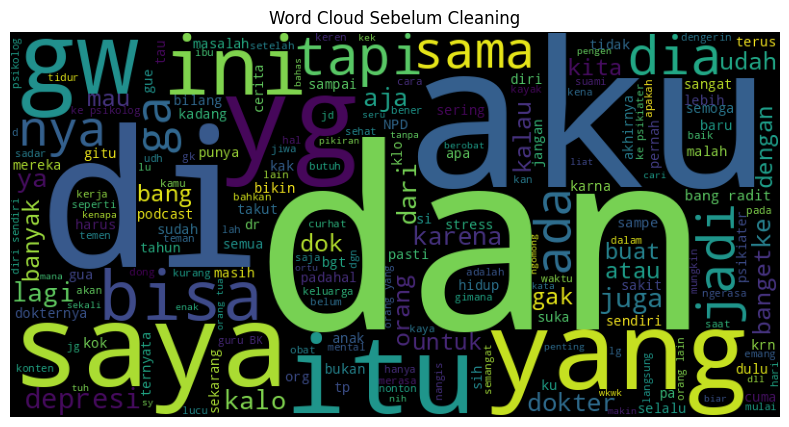

In [28]:
from wordcloud import WordCloud

text_before = " ".join(df['komentar'].astype(str))

wordcloud = WordCloud(width=800, height=400).generate(text_before)

plt.figure(figsize=(15,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Word Cloud Sebelum Cleaning")
plt.show()

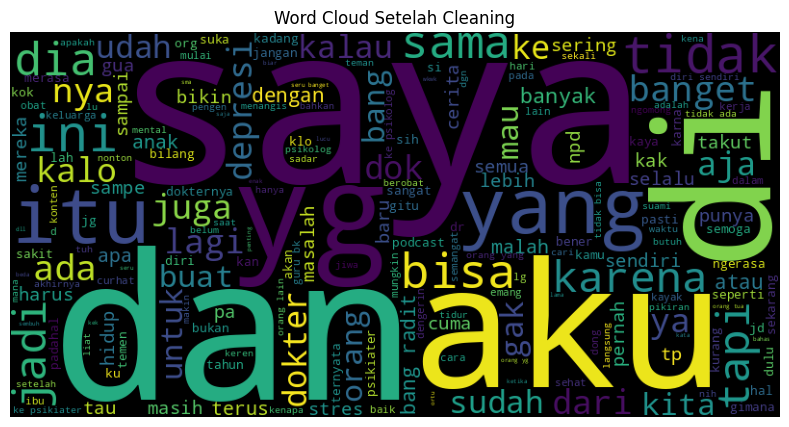

In [29]:
text_after = " ".join(df['normalized'].astype(str))

wordcloud = WordCloud(width=800, height=400).generate(text_after)

plt.figure(figsize=(15,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Word Cloud Setelah Cleaning")
plt.show()